# KNN Regressor

### Jane Dalessio

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Basic Data Inspection

In [7]:
seoul_bike_data = pd.read_csv("SeoulBikeData.csv", encoding = "unicode_escape")
seoul_bike_data.head()


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Separate the Date Column

In [85]:
seoul_bike_data["Date"] = pd.to_datetime(seoul_bike_data["Date"], format="%d/%m/%Y")
seoul_bike_data["Month"] = seoul_bike_data["Date"].dt.month
seoul_bike_data["Day_of_week"] = seoul_bike_data["Date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
 
seoul_bike_data = seoul_bike_data.drop(columns=["Date"])
seoul_bike_data.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Day_of_week
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4


### Separate Features and Target

In [101]:
target_col = "Rented Bike Count"
y = seoul_bike_data[target_col]
X = seoul_bike_data.drop(columns=[target_col])

### Encode the Season Categorical Column

In [104]:
X = pd.get_dummies(X, columns=["Seasons"], drop_first=True)
seoul_bike_data["Holiday"] = seoul_bike_data["Holiday"].map({"No Holiday": 0, "Holiday": 1})
seoul_bike_data["Functioning Day"] = seoul_bike_data["Functioning Day"].map({"No": 0, "Yes": 1})
 
print("\nFeatures after encoding:")
print(X.columns.tolist())


Features after encoding:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Month', 'Day_of_week', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter']


### Time-based Train/Test Split: first ~9 months = train, last ~3 months = test

In [109]:
# The dataset has 8,760 hourly rows = 365 days
# 9 months ≈ 273 days = 6,552 rows
split_index = 6552
 
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
 
print(f"\nTraining samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")


Training samples:  6552
Testing samples:   2208


### Scale Features

In [112]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Tune k using TimeSeriesSplit cross-validation

k=  1  |  CV RMSE: 480.15
k=  3  |  CV RMSE: 439.83
k=  5  |  CV RMSE: 435.62
k= 10  |  CV RMSE: 436.42
k= 15  |  CV RMSE: 440.86
k= 20  |  CV RMSE: 443.26
k= 30  |  CV RMSE: 449.72


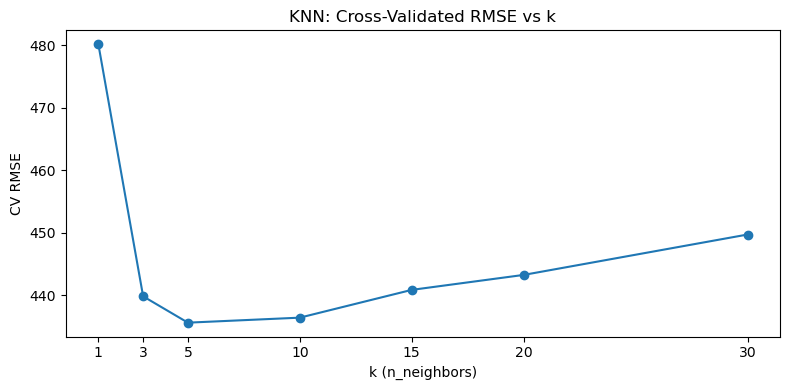

Saved k-tuning plot to knn_k_tuning.png


In [115]:
tscv = TimeSeriesSplit(n_splits=5)
k_values = [1, 3, 5, 10, 15, 20, 30]
cv_rmse_scores = []
 
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    # cross_val_score returns negative MSE by convention; negate and sqrt for RMSE
    mse_scores = -cross_val_score(
        knn, X_train_scaled, y_train,
        cv=tscv, scoring="neg_mean_squared_error"
    )
    rmse = np.sqrt(mse_scores).mean()
    cv_rmse_scores.append(rmse)
    print(f"k={k:>3}  |  CV RMSE: {rmse:.2f}")
 
# Plot RMSE vs k
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_rmse_scores, marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("CV RMSE")
plt.title("KNN: Cross-Validated RMSE vs k")
plt.xticks(k_values)
plt.tight_layout()
plt.savefig("knn_k_tuning.png", dpi=150)
plt.show()
print("Saved k-tuning plot to knn_k_tuning.png")

### Fit best model and evaluate on held-out test set

In [118]:
best_k = k_values[np.argmin(cv_rmse_scores)]
print(f"\nBest k from CV: {best_k}")
 
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
 
print(f"\n--- Final KNN Test Results (k={best_k}) ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")


Best k from CV: 5

--- Final KNN Test Results (k=5) ---
RMSE: 487.70
MAE:  340.05
R²:   0.4410
